In [ ]:
# Módulo 6 sesión 5, clase 31/07
# Datos Sintéticos para Clasificación

# Importar librerías necesarias
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification, load_iris # Para generar datos de clasificación
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler # Para escalado de datos en K-NN y SVM

print("Librerías importadas correctamente.")

# Generar un conjunto de datos sintético para problemas de clasificación binaria
# 'n_samples': número de observaciones/muestras
# 'n_features': número de características (variables independientes)
# 'n_informative': número de características que realmente contribuyen a la clasificación
# 'n_redundant': número de características que son combinaciones lineales de otras
# 'n_classes': número de clases en la variable objetivo (binaria en este caso: 0 o 1)
# 'random_state': para reproducibilidad
X_clasif, y_clasif = make_classification(n_samples=200, n_features=4, n_informative=2,
                                        n_redundant=0, n_classes=2, random_state=42)

print(f"\nConjunto de datos sintético generado:")
print(f"  Forma de las características (X): {X_clasif.shape}")
print(f"  Forma de las etiquetas (y): {y_clasif.shape}")
print(f"  Ejemplo de las primeras 5 filas de X:\n{X_clasif[:5]}")
print(f"  Ejemplo de las primeras 5 etiquetas de y:\n{y_clasif[:5]}")

# Dividir los datos en conjuntos de entrenamiento y prueba
# 'test_size=0.25': 25% de los datos para prueba, 75% para entrenamiento
# 'stratify=y_clasif': Mantiene la misma proporción de clases en los conjuntos de entrenamiento y prueba
X_train_clasif, X_test_clasif, y_train_clasif, y_test_clasif = train_test_split(
    X_clasif, y_clasif, test_size=0.25, random_state=42, stratify=y_clasif
)

print(f"\nDatos divididos en entrenamiento y prueba:")
print(f"  Tamaño de X_train: {X_train_clasif.shape}, y_train: {y_train_clasif.shape}")
print(f"  Tamaño de X_test: {X_test_clasif.shape}, y_test: {y_test_clasif.shape}")

Librerías importadas correctamente.

Conjunto de datos sintético generado:
  Forma de las características (X): (200, 4)
  Forma de las etiquetas (y): (200,)
  Ejemplo de las primeras 5 filas de X:
[[ 1.48831208  1.02915564  0.47259748 -0.00310025]
 [ 1.21580074  0.4134349   1.87679581 -0.50889742]
 [ 0.95243439 -0.03498849  1.77080064  0.73969966]
 [ 1.59497041 -1.08105654  1.05315285  1.21166003]
 [ 0.57535808 -0.54491909  0.39913611  1.48036239]]
  Ejemplo de las primeras 5 etiquetas de y:
[1 1 1 1 1]

Datos divididos en entrenamiento y prueba:
  Tamaño de X_train: (150, 4), y_train: (150,)
  Tamaño de X_test: (50, 4), y_test: (50,)


In [ ]:
# 1. Regresión Logística
# La Regresión Logística es un algoritmo de aprendizaje supervisado utilizado principalmente para problemas de clasificación binaria.
# Aunque su nombre incluye "regresión", no se usa para predecir valores continuos, sino para estimar la probabilidad de que una observación
#pertenezca a una clase específica. La función sigmoidea o función logística es clave en este modelo, transformando cualquier valor real en
# un rango entre 0 y 1,
# representando una probabilidad.
# --- 1. Regresión Logística ---
print("\n--- Modelo de Clasificación: Regresión Logística ---")

from sklearn.linear_model import LogisticRegression

# Crear una instancia del modelo de Regresión Logística
# 'max_iter': Aumentado para asegurar la convergencia en datasets más complejos
# 'random_state': Para reproducibilidad de los resultados
# 'solver': Algoritmo a utilizar para la optimización. 'liblinear' es bueno para datasets pequeños.
model_lr = LogisticRegression(max_iter=200, random_state=42, solver='liblinear')

# Entrenar el modelo con los datos de entrenamiento
print("Entrenando el modelo de Regresión Logística...")
model_lr.fit(X_train_clasif, y_train_clasif)
# Imprimir los parámetros del modelo
print("\nParámetros del modelo:")
print(model_lr.get_params())

# Realizar predicciones sobre el conjunto de prueba
y_pred_lr = model_lr.predict(X_test_clasif)

# Calcular las probabilidades de pertenencia a la clase positiva
# Esto es útil para entender la confianza del modelo en sus predicciones
y_pred_proba_lr = model_lr.predict_proba(X_test_clasif)[:, 1] # Probabilidad de la clase 1

# Evaluar el modelo
print("\nEvaluación del Modelo de Regresión Logística:")
accuracy_lr = accuracy_score(y_test_clasif, y_pred_lr)
conf_matrix_lr = confusion_matrix(y_test_clasif, y_pred_lr)
class_report_lr = classification_report(y_test_clasif, y_pred_lr)

print(f"  Exactitud (Accuracy): {accuracy_lr:.2f}")
print(f"  Matriz de Confusión:\n{conf_matrix_lr}")
print(f"  Reporte de Clasificación:\n{class_report_lr}")

print("\nInterpretación de la Matriz de Confusión:")
print("  [[Verdaderos Negativos (TN), Falsos Positivos (FP)]")
print("   [Falsos Negativos (FN), Verdaderos Positivos (TP)]]")
print(f"\nValores predichos (primeras 10): {y_pred_lr[:10]}")
print(f"Valores reales (primeras 10):   {y_test_clasif[:10]}")
print(f"Probabilidades predichas de clase 1 (primeras 10): {y_pred_proba_lr[:10].round(2)}")


--- Modelo de Clasificación: Regresión Logística ---
Entrenando el modelo de Regresión Logística...

Parámetros del modelo:
{'C': 1.0, 'class_weight': None, 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': None, 'max_iter': 200, 'multi_class': 'deprecated', 'n_jobs': None, 'penalty': 'l2', 'random_state': 42, 'solver': 'liblinear', 'tol': 0.0001, 'verbose': 0, 'warm_start': False}

Evaluación del Modelo de Regresión Logística:
  Exactitud (Accuracy): 0.82
  Matriz de Confusión:
[[19  6]
 [ 3 22]]
  Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.86      0.76      0.81        25
           1       0.79      0.88      0.83        25

    accuracy                           0.82        50
   macro avg       0.82      0.82      0.82        50
weighted avg       0.82      0.82      0.82        50


Interpretación de la Matriz de Confusión:
  [[Verdaderos Negativos (TN), Falsos Positivos (FP)]
   [Falsos Negativos

Exactitud (Accuracy): 0.82

Qué es: La exactitud o accuracy es la métrica más sencilla y común. Representa la proporción de predicciones correctas (tanto positivos como negativos) sobre el total de predicciones.

Interpretación: Un Accuracy de 0.82 (o 82%) significa que el modelo clasificó correctamente el 82% de las observaciones en el conjunto de prueba. Es un buen punto de partida, pero no siempre es suficiente por sí solo, especialmente si las clases están desbalanceadas.

5. Matriz de Confusión:

Qué es: Es una tabla que resume el rendimiento de un algoritmo de clasificación, mostrando el número de predicciones correctas e incorrectas para cada clase.

Estructura y tu salida:

[[19  6]  <- Fila para la clase 0 (Negativa)
 [ 3 22]] <- Fila para la clase 1 (Positiva)
Interpretación detallada (basada en tu explicación [[TN, FP], [FN, TP]]):

Verdaderos Negativos (TN): 19

El modelo predijo correctamente 19 casos como Clase 0 (negativa) cuando realmente eran Clase 0.

Falsos Positivos (FP): 6

El modelo predijo 6 casos como Clase 1 (positiva) cuando en realidad eran Clase 0. Estos son errores de "Tipo I" o "falsas alarmas".

Falsos Negativos (FN): 3

El modelo predijo 3 casos como Clase 0 (negativa) cuando en realidad eran Clase 1. Estos son errores de "Tipo II" o "fallos de detección".

Verdaderos Positivos (TP): 22

El modelo predijo correctamente 22 casos como Clase 1 (positiva) cuando realmente eran Clase 1.

Total de muestras en el conjunto de prueba: 19+6+3+22=50 (coincide con el support total en el reporte de clasificación).

Total de clase 0 (real): 19+6=25

Total de clase 1 (real): 3+22=25

Tus clases están balanceadas en el conjunto de prueba (25 de cada una).

6. Reporte de Clasificación:

Qué es: Proporciona un resumen más detallado del rendimiento por clase, incluyendo Precision, Recall y F1-Score, además de la Exactitud general y el support (número de muestras reales por clase).

precision (Precisión):

Clase 0: 0.86 (19/(19+3)) = De todas las veces que el modelo predijo "Clase 0", el 86% fueron correctas.

Clase 1: 0.79 (22/(6+22)) = De todas las veces que el modelo predijo "Clase 1", el 79% fueron correctas.

Interpretación: Mide la exactitud de las predicciones positivas. Un valor alto significa pocos Falsos Positivos.

recall (Sensibilidad o Exhaustividad):

Clase 0: 0.76 (19/(19+6)) = De todos los casos que realmente eran "Clase 0", el modelo identificó correctamente el 76%.

Clase 1: 0.88 (22/(3+22)) = De todos los casos que realmente eran "Clase 1", el modelo identificó correctamente el 88%.

Interpretación: Mide la capacidad del modelo para encontrar todas las instancias positivas (o negativas). Un valor alto significa pocos Falsos Negativos.

f1-score (Puntuación F1):

Clase 0: 0.81

Clase 1: 0.83

Interpretación: Es la media armónica de precisión y recall. Es útil cuando buscas un equilibrio entre precisión y recall, especialmente en clases desbalanceadas (aunque tus clases son balanceadas aquí). Un F1-score alto indica que el modelo tiene un buen rendimiento en ambas métricas.

support:

Clase 0: 25

Clase 1: 25

Interpretación: El número real de ocurrencias de cada clase en el conjunto de prueba.

accuracy (general): 0.82

Corresponde a la Exactitud general que ya vimos.

macro avg (promedio macro):

Calcula el promedio no ponderado de las métricas (precision, recall, f1-score) para cada clase. Útil cuando se quiere dar igual importancia a cada clase, sin importar su tamaño.

weighted avg (promedio ponderado):

Calcula el promedio de las métricas ponderado por el número de instancias de cada clase (support). Esto es más útil para clases desbalanceadas, ya que da más peso a las clases más grandes. Para tu caso, como las clases están balanceadas, macro avg y weighted avg son casi idénticos.

7. Valores predichos (primeras 10): [1 1 1 1 0 0 0 1 0 0]
8. Valores reales (primeras 10):   [1 1 1 0 0 0 0 1 0 1]

Propósito: Estas líneas te muestran una pequeña muestra de las predicciones del modelo frente a los valores reales. Puedes compararlos directamente para ver dónde el modelo acertó o falló. Por ejemplo:

Pred: 1, Real: 1 (Correcto)

Pred: 1, Real: 0 (Falso Positivo)

Pred: 0, Real: 1 (Falso Negativo)

9. Probabilidades predichas de clase 1 (primeras 10): [0.8  0.84 1.   0.99 0.48 0.19 0.26 0.99 0.09 0.09]

Qué es: La regresión logística, en su núcleo, predice probabilidades. Estos son los valores que el modelo asigna a cada observación de prueba para pertenecer a la Clase 1.

Interpretación:

Por ejemplo, para la primera muestra, el modelo predice una probabilidad de 0.80 (80%) de ser Clase 1. Como 0.80 > 0.50 (el umbral predeterminado), el modelo la clasifica como 1.

Para la quinta muestra, la probabilidad es 0.48. Como 0.48 < 0.50, el modelo la clasifica como 0. Esto fue correcto, ya que el valor real también es 0.

Para la décima muestra, la probabilidad es 0.09. El modelo la clasifica como 0. Sin embargo, el valor real es 1. Esta es una falsa negativa. El modelo estaba muy seguro de que era clase 0 (probabilidad muy baja para clase 1), pero se equivocó.

El modelo de Regresión Logística está funcionando razonablemente bien con una exactitud del 82%. La Matriz de Confusión te da un desglose de los aciertos y errores, y el Reporte de Clasificación te proporciona métricas más detalladas por clase, que son cruciales para entender el rendimiento en diferentes escenarios. Las probabilidades te muestran la confianza del modelo en sus predicciones, lo cual es muy valioso para decisiones posteriores.

In [ ]:
# 2. K-Nearest Neighbors (K-NN)
# K-NN es un método de aprendizaje supervisado que se basa en instancias, lo que significa que no aprende un modelo explícito, sino que
# utiliza los datos directamente para hacer predicciones. Dado un nuevo dato, el algoritmo encuentra los 'k' puntos más cercanos en el
# conjunto de entrenamiento y utiliza sus etiquetas para predecir la etiqueta del nuevo dato. Es crucial escalar los datos para K-NN, ya
# que se basa en medidas de distancia y las variables con diferentes escalas pueden sesgar los resultados.
# --- 2. K-Nearest Neighbors (K-NN) ---
print("\n--- Modelo de Clasificación: K-Nearest Neighbors (K-NN) ---")

from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler # Para escalado de datos

# El escalado de datos es crucial para K-NN
# StandardScaler: Transforma los datos para que tengan media 0 y desviación estándar 1 (Estandarización)
scaler = StandardScaler()

# Ajustar el escalador solo con los datos de entrenamiento y luego transformar ambos conjuntos
print("Escalando los datos...")
X_train_scaled_knn = scaler.fit_transform(X_train_clasif)
X_test_scaled_knn = scaler.transform(X_test_clasif)

print(f"  Ejemplo de X_train escalado (primeras 5 filas):\n{X_train_scaled_knn[:5].round(2)}")
print(f"  Ejemplo de X_test escalado (primeras 5 filas):\n{X_test_scaled_knn[:5].round(2)}")

# Crear una instancia del modelo K-NN
# 'n_neighbors': El valor de 'k'. Un valor común es 3 o 5, pero se optimiza con validación cruzada.
# 'metric': La métrica de distancia a usar. 'minkowski' con p=2 (Euclidiana) es la predeterminada.
# El PDF menciona la distancia Euclidiana[cite: 39].
model_knn = KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=2)

# Entrenar el modelo con los datos de entrenamiento escalados
print("\nEntrenando el modelo K-NN...")
model_knn.fit(X_train_scaled_knn, y_train_clasif)

# Realizar predicciones sobre el conjunto de prueba escalado
y_pred_knn = model_knn.predict(X_test_scaled_knn)

# Evaluar el modelo
print("\nEvaluación del Modelo K-NN:")
accuracy_knn = accuracy_score(y_test_clasif, y_pred_knn)
conf_matrix_knn = confusion_matrix(y_test_clasif, y_pred_knn)
class_report_knn = classification_report(y_test_clasif, y_pred_knn)

print(f"  Exactitud (Accuracy): {accuracy_knn:.2f}")
print(f"  Matriz de Confusión:\n{conf_matrix_knn}")
print(f"  Reporte de Clasificación:\n{class_report_knn}")

print(f"\nValores predichos (primeras 10): {y_pred_knn[:10]}")
print(f"Valores reales (primeras 10):   {y_test_clasif[:10]}")


--- Modelo de Clasificación: K-Nearest Neighbors (K-NN) ---
Escalando los datos...
  Ejemplo de X_train escalado (primeras 5 filas):
[[ 0.02 -0.19 -0.88 -1.76]
 [-0.37  0.77 -1.06 -1.39]
 [ 0.49 -0.67 -1.33  0.26]
 [-0.84  1.49  0.17 -1.42]
 [ 1.17 -0.33 -0.91 -0.6 ]]
  Ejemplo de X_test escalado (primeras 5 filas):
[[ 0.78 -0.09  1.8   0.47]
 [ 0.69 -0.78 -0.19  0.64]
 [ 2.28 -2.09 -0.94  0.39]
 [ 1.49  0.53 -0.25  0.5 ]
 [-0.15 -0.57 -0.99 -0.72]]

Entrenando el modelo K-NN...

Evaluación del Modelo K-NN:
  Exactitud (Accuracy): 0.78
  Matriz de Confusión:
[[19  6]
 [ 5 20]]
  Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.79      0.76      0.78        25
           1       0.77      0.80      0.78        25

    accuracy                           0.78        50
   macro avg       0.78      0.78      0.78        50
weighted avg       0.78      0.78      0.78        50


Valores predichos (primeras 10): [1 1 1 1 0 0 0 1 0 0]
Valo

Contexto de K-NN: El escalado es crucial para K-NN. Este algoritmo se basa en el cálculo de distancias entre puntos (por defecto, distancia euclidiana). Si tus características tienen rangos de valores muy diferentes (por ejemplo, una característica de 1 a 10 y otra de 1 a 1000), la característica con el rango más grande dominaría el cálculo de la distancia, haciendo que las diferencias en otras características más pequeñas sean insignificantes.

StandardScaler: El código utiliza StandardScaler, que transforma los datos para que tengan una media de 0 y una desviación estándar de 1. Esto asegura que todas las características contribuyan de manera equitativa al cálculo de la distancia, mejorando el rendimiento del modelo.

Ejemplo de X_train escalado (primeras 5 filas): y Ejemplo de X_test escalado (primeras 5 filas):

Qué es: Muestra las primeras 5 filas de tus datos de entrenamiento y prueba después de haber sido escalados.

Interpretación: Observa que los valores originales (que no se muestran aquí, pero los generaste antes) han sido transformados a un rango alrededor de 0, con valores tanto positivos como negativos, y con una dispersión estándar. Esto confirma que el escalado se aplicó correctamente. Por ejemplo, un valor como -1.76 en la primera fila de X_train indica que esa observación estaba 1.76 desviaciones estándar por debajo de la media en esa característica particular.

Exactitud (Accuracy): 0.78

Qué es: La proporción de predicciones correctas sobre el total de predicciones en el conjunto de prueba.

Interpretación: Un Accuracy de 0.78 (o 78%) significa que el modelo K-NN clasificó correctamente el 78% de las observaciones en tu conjunto de prueba. Esto es un poco más bajo que la Regresión Logística (82%).

7. Matriz de Confusión:

Qué es: Un resumen del rendimiento de la clasificación.

Estructura y tu salida:

[[19  6]  <- Fila para la clase 0 (Negativa)
 [ 5 20]] <- Fila para la clase 1 (Positiva)
Interpretación:

Verdaderos Negativos (TN): 19

19 casos predichos correctamente como Clase 0 (eran realmente Clase 0).

Falsos Positivos (FP): 6

6 casos predichos como Clase 1, pero que eran Clase 0 (errores de Tipo I).

Falsos Negativos (FN): 5

5 casos predichos como Clase 0, pero que eran Clase 1 (errores de Tipo II).

Verdaderos Positivos (TP): 20

20 casos predichos correctamente como Clase 1 (eran realmente Clase 1).

Comparación con Regresión Logística:

K-NN tiene la misma cantidad de FN que la Regresión Logística (6 FP), pero ligeramente más FN (5 vs 3). Esto indica que K-NN tuvo un poco más de problemas para identificar la clase 1 cuando realmente lo era.

8. Reporte de Clasificación:

Qué es: Proporciona un resumen detallado del rendimiento por clase.

precision (Precisión):

Clase 0: 0.79 (19/(19+5)) = De las veces que el modelo predijo "Clase 0", el 79% fueron correctas.

Clase 1: 0.77 (20/(6+20)) = De las veces que el modelo predijo "Clase 1", el 77% fueron correctas.

Interpretación: La precisión para ambas clases es similar, alrededor del 77-79%.

recall (Sensibilidad o Exhaustividad):

Clase 0: 0.76 (19/(19+6)) = De todos los casos reales "Clase 0", el modelo identificó el 76% correctamente.

Clase 1: 0.80 (20/(5+20)) = De todos los casos reales "Clase 1", el modelo identificó el 80% correctamente.

Interpretación: El recall para la Clase 1 es ligeramente mejor que para la Clase 0, lo que significa que el modelo es un poco mejor en identificar todos los casos positivos reales.

f1-score (Puntuación F1):

Clase 0: 0.78

Clase 1: 0.78

Interpretación: La puntuación F1, que busca un equilibrio entre precisión y recall, es la misma para ambas clases (0.78), indicando un rendimiento balanceado en la identificación de ambas clases.

support:

Clase 0: 25

Clase 1: 25

Interpretación: El número real de instancias de cada clase en el conjunto de prueba, confirmando el balance.

accuracy (general): 0.78

macro avg y weighted avg: Los promedios de las métricas, que son idénticos a la exactitud general porque las clases están balanceadas.

9. Valores predichos (primeras 10): [1 1 1 1 0 0 0 1 0 0]
10. Valores reales (primeras 10):   [1 1 1 0 0 0 0 1 0 1]

Propósito: Muestra un pequeño extracto de las predicciones del modelo frente a los valores reales para una inspección rápida.

El modelo K-NN con un k=5 (vecinos) y datos escalados alcanzó una exactitud del 78%. Aunque es ligeramente inferior a tu modelo de Regresión Logística (82%), sigue siendo un rendimiento aceptable. La importancia del escalado de datos para K-NN se destaca en esta salida, ya que sin él, el rendimiento podría ser mucho peor. Las métricas detalladas (precisión, recall, F1-score) muestran que el modelo se desempeña de manera similar para ambas clases, lo cual es bueno dado que tu dataset está balanceado.

In [ ]:
# 3. Árbol de Decisión
# Un Árbol de Decisión es un algoritmo de aprendizaje supervisado que utiliza un modelo basado en reglas para dividir recursivamente
# el conjunto de datos en subconjuntos más pequeños y homogéneos. Es fácil de entender y visualizar, y no requiere escalamiento de datos.
# Sin embargo, son propensos al sobreajuste (overfitting).
# --- 3. Árbol de Decisión para Clasificación ---
print("\n--- Modelo de Clasificación: Árbol de Decisión ---")

from sklearn.tree import DecisionTreeClassifier
# Puedes importar graphviz y export_graphviz para visualizar el árbol si lo deseas (requiere instalación)
# from sklearn.tree import export_graphviz
# import graphviz

# Crear una instancia del modelo de Árbol de Decisión
# 'max_depth': Profundidad máxima del árbol. Un valor más bajo limita la complejidad (previene overfitting)[cite: 62].
# 'criterion': Medida de impureza utilizada para evaluar las divisiones. 'gini' o 'entropy' para clasificación[cite: 63].
# 'random_state': Para reproducibilidad.
model_dt = DecisionTreeClassifier(max_depth=5, criterion='gini', random_state=42)

# Entrenar el modelo con los datos de entrenamiento (no se necesita escalado)
print("Entrenando el modelo de Árbol de Decisión...")
model_dt.fit(X_train_clasif, y_train_clasif)

# Realizar predicciones sobre el conjunto de prueba
y_pred_dt = model_dt.predict(X_test_clasif)

# Evaluar el modelo
print("\nEvaluación del Modelo de Árbol de Decisión:")
accuracy_dt = accuracy_score(y_test_clasif, y_pred_dt)
conf_matrix_dt = confusion_matrix(y_test_clasif, y_pred_dt)
class_report_dt = classification_report(y_test_clasif, y_pred_dt)

print(f"  Exactitud (Accuracy): {accuracy_dt:.2f}")
print(f"  Matriz de Confusión:\n{conf_matrix_dt}")
print(f"  Reporte de Clasificación:\n{class_report_dt}")

print(f"\nValores predichos (primeras 10): {y_pred_dt[:10]}")
print(f"Valores reales (primeras 10):   {y_test_clasif[:10]}")

# Opcional: Visualizar el árbol (requiere instalar graphviz: pip install graphviz)
# dot_data = export_graphviz(model_dt, out_file=None,
#                            feature_names=['feature_0', 'feature_1', 'feature_2', 'feature_3'],
#                            class_names=['0', '1'],
#                            filled=True, rounded=True, special_characters=True)
# graph = graphviz.Source(dot_data)
# graph.render("arbol_decision", view=True) # Esto guardará un PDF y lo abrirá


--- Modelo de Clasificación: Árbol de Decisión ---
Entrenando el modelo de Árbol de Decisión...

Evaluación del Modelo de Árbol de Decisión:
  Exactitud (Accuracy): 0.76
  Matriz de Confusión:
[[18  7]
 [ 5 20]]
  Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.78      0.72      0.75        25
           1       0.74      0.80      0.77        25

    accuracy                           0.76        50
   macro avg       0.76      0.76      0.76        50
weighted avg       0.76      0.76      0.76        50


Valores predichos (primeras 10): [1 1 0 1 0 0 0 1 0 0]
Valores reales (primeras 10):   [1 1 1 0 0 0 0 1 0 1]


Entrenando el modelo de Árbol de Decisión
El método fit() del DecisionTreeClassifier está siendo ejecutado. Durante esta fase, el algoritmo construye el árbol, decidiendo las mejores divisiones de los datos en cada nodo para separar las clases de la manera más pura posible. No requiere escalado de datos porque se basa en umbrales de características, no en distancias.

Exactitud (Accuracy): 0.76

Qué es: La proporción de predicciones correctas (verdaderos positivos y verdaderos negativos) sobre el total de predicciones.

Interpretación: Un Accuracy de 0.76 (o 76%) significa que el Árbol de Decisión clasificó correctamente el 76% de las observaciones en tu conjunto de prueba. Esto es ligeramente inferior a la Regresión Logística (82%) y K-NN (78%).

5. Matriz de Confusión:

Qué es: Una tabla que resume las predicciones del modelo frente a los valores reales.

Estructura y tu salida:

[[18  7]  <- Fila para la clase 0 (Realmente Negativa)
 [ 5 20]] <- Fila para la clase 1 (Realmente Positiva)
Interpretación detallada (siguiendo la estructura [[TN, FP], [FN, TP]]):

Verdaderos Negativos (TN): 18

El modelo predijo correctamente 18 casos como Clase 0 cuando realmente eran Clase 0.

Falsos Positivos (FP): 7

El modelo predijo 7 casos como Clase 1 cuando en realidad eran Clase 0. Estos son errores de "Tipo I" (falsas alarmas). Es el número más alto de FPs hasta ahora en tus modelos.

Falsos Negativos (FN): 5

El modelo predijo 5 casos como Clase 0 cuando en realidad eran Clase 1. Estos son errores de "Tipo II" (fallos de detección).

Verdaderos Positivos (TP): 20

El modelo predijo correctamente 20 casos como Clase 1 cuando realmente eran Clase 1.

Observación: En comparación con la Regresión Logística (6 FP) y K-NN (6 FP), el Árbol de Decisión tiene un número un poco mayor de Falsos Positivos (7). El número de Falsos Negativos (5) es igual al de K-NN y mayor que el de la Regresión Logística (3).

6. Reporte de Clasificación:

Qué es: Un informe detallado que incluye Precisión, Recall y F1-Score por clase.

precision (Precisión):

Clase 0: 0.78 (18/(18+5)) = De todas las veces que el modelo predijo "Clase 0", el 78% fueron correctas.

Clase 1: 0.74 (20/(7+20)) = De todas las veces que el modelo predijo "Clase 1", el 74% fueron correctas.

Interpretación: La precisión de la Clase 1 es la más baja hasta ahora (0.74), lo que se alinea con el mayor número de Falsos Positivos para esta clase.

recall (Sensibilidad o Exhaustividad):

Clase 0: 0.72 (18/(18+7)) = De todos los casos que realmente eran "Clase 0", el modelo identificó correctamente el 72%.

Clase 1: 0.80 (20/(5+20)) = De todos los casos que realmente eran "Clase 1", el modelo identificó correctamente el 80%.

Interpretación: El recall para la Clase 0 es el más bajo hasta ahora (0.72), lo que indica que el modelo "perdió" más casos reales de la Clase 0 (los clasificó incorrectamente como 1). El recall para la Clase 1 es bueno (0.80).

f1-score (Puntuación F1):

Clase 0: 0.75

Clase 1: 0.77

Interpretación: Un equilibrio decente, aunque ligeramente inferior a K-NN y Regresión Logística.

support:

Clase 0: 25

Clase 1: 25

Interpretación: El número de muestras reales para cada clase en el conjunto de prueba, confirmando que el dataset está balanceado.

accuracy (general): 0.76

macro avg y weighted avg: Los promedios de las métricas, que son consistentes con la exactitud general debido al balanceo de clases.

7. Valores predichos (primeras 10): [1 1 0 1 0 0 0 1 0 0]
8. Valores reales (primeras 10):   [1 1 1 0 0 0 0 1 0 1]

Propósito: Muestra un pequeño extracto de las predicciones del modelo frente a los valores reales para una inspección rápida.

El modelo de Árbol de Decisión (con max_depth=5) logró una exactitud del 76%. Aunque es un buen rendimiento, fue ligeramente superado por la Regresión Logística y K-NN en este conjunto de datos particular. El árbol de decisión mostró una tendencia a tener más Falsos Positivos y un menor recall para la Clase 0, lo que significa que a veces clasificó incorrectamente un caso de Clase 0 como Clase 1. La elección del max_depth es crucial para los árboles de decisión, ya que un árbol demasiado profundo podría sobreajustarse.

In [ ]:
# 4. Bosques Aleatorios
# Los Bosques Aleatorios (Random Forests) son un algoritmo de aprendizaje supervisado que utiliza una técnica de ensamblado (ensemble)
# llamada "bagging" (Bootstrap Aggregating). Combina múltiples árboles de decisión entrenados en diferentes subconjuntos de datos para mejorar
# la precisión y reducir el sobreajuste.
# --- 4. Bosques Aleatorios (Random Forest) ---
print("\n--- Modelo de Clasificación: Bosques Aleatorios ---")

from sklearn.ensemble import RandomForestClassifier

# Crear una instancia del modelo de Bosques Aleatorios
# 'n_estimators': Número de árboles en el bosque. Más árboles generalmente mejoran la precisión, pero aumentan el tiempo de cálculo.
# 'max_depth': Profundidad máxima para cada árbol individual (similar al Árbol de Decisión).
# 'random_state': Para reproducibilidad.
model_rf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)

# Entrenar el modelo con los datos de entrenamiento (no se necesita escalado)
print("Entrenando el modelo de Bosques Aleatorios...")
model_rf.fit(X_train_clasif, y_train_clasif)

# Realizar predicciones sobre el conjunto de prueba
y_pred_rf = model_rf.predict(X_test_clasif)

# Evaluar el modelo
print("\nEvaluación del Modelo de Bosques Aleatorios:")
accuracy_rf = accuracy_score(y_test_clasif, y_pred_rf)
conf_matrix_rf = confusion_matrix(y_test_clasif, y_pred_rf)
class_report_rf = classification_report(y_test_clasif, y_pred_rf)

print(f"  Exactitud (Accuracy): {accuracy_rf:.2f}")
print(f"  Matriz de Confusión:\n{conf_matrix_rf}")
print(f"  Reporte de Clasificación:\n{class_report_rf}")

print(f"\nValores predichos (primeras 10): {y_pred_rf[:10]}")
print(f"Valores reales (primeras 10):   {y_test_clasif[:10]}")

# Opcional: Ver la importancia de las características
# Random Forest puede indicar qué características fueron más importantes para las decisiones del modelo
print("\nImportancia de las características según Random Forest:")
for i, importance in enumerate(model_rf.feature_importances_):
    print(f"  Característica {i}: {importance:.4f}")


--- Modelo de Clasificación: Bosques Aleatorios ---
Entrenando el modelo de Bosques Aleatorios...

Evaluación del Modelo de Bosques Aleatorios:
  Exactitud (Accuracy): 0.80
  Matriz de Confusión:
[[19  6]
 [ 4 21]]
  Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.83      0.76      0.79        25
           1       0.78      0.84      0.81        25

    accuracy                           0.80        50
   macro avg       0.80      0.80      0.80        50
weighted avg       0.80      0.80      0.80        50


Valores predichos (primeras 10): [1 1 1 1 0 0 0 1 0 0]
Valores reales (primeras 10):   [1 1 1 0 0 0 0 1 0 1]

Importancia de las características según Random Forest:
  Característica 0: 0.6779
  Característica 1: 0.1218
  Característica 2: 0.0810
  Característica 3: 0.1192


Explicación de la Salida del Bosque Aleatorio
Se muestra cómo se entrenó y evaluó el modelo de Bosques Aleatorios.

1. --- Modelo de Clasificación: Bosques Aleatorios ---


2. Entrenando el modelo de Bosques Aleatorios...

El método fit() del RandomForestClassifier está siendo ejecutado. Durante esta fase, el algoritmo construye múltiples árboles de decisión (100 en tu caso, según n_estimators=100) en diferentes subconjuntos de los datos de entrenamiento (con muestreo con reemplazo, conocido como bagging). Cada árbol se entrena de forma independiente, y las predicciones finales se obtienen combinando las predicciones de todos los árboles (por votación mayoritaria para clasificación). Al igual que los Árboles de Decisión individuales, los Bosques Aleatorios no requieren escalado de datos.

Exactitud (Accuracy): 0.80

Qué es: La proporción de predicciones correctas sobre el total de predicciones.

Interpretación: Un Accuracy de 0.80 (o 80%) significa que el Bosque Aleatorio clasificó correctamente el 80% de las observaciones en tu conjunto de prueba. Esto es un buen rendimiento, superando al Árbol de Decisión individual (76%) y K-NN (78%), y acercándose al rendimiento de la Regresión Logística (82%). Esto demuestra el poder de los métodos de ensamblado.

5. Matriz de Confusión:

Qué es: Una tabla que resume las predicciones del modelo frente a los valores reales.

Estructura y tu salida:

[[19  6]  <- Fila para la clase 0 (Realmente Negativa)
 [ 4 21]] <- Fila para la clase 1 (Realmente Positiva)
Interpretación detallada (siguiendo la estructura [[TN, FP], [FN, TP]]):

Verdaderos Negativos (TN): 19

El modelo predijo correctamente 19 casos como Clase 0 cuando realmente eran Clase 0.

Falsos Positivos (FP): 6

El modelo predijo 6 casos como Clase 1 cuando en realidad eran Clase 0. Estos son errores de "Tipo I" (falsas alarmas). Es igual que la Regresión Logística y K-NN.

Falsos Negativos (FN): 4

El modelo predijo 4 casos como Clase 0 cuando en realidad eran Clase 1. Estos son errores de "Tipo II" (fallos de detección). Es menos que K-NN (5) y el Árbol de Decisión (5), pero más que la Regresión Logística (3).

Verdaderos Positivos (TP): 21

El modelo predijo correctamente 21 casos como Clase 1 cuando realmente eran Clase 1. Este es un buen número de TP.

6. Reporte de Clasificación:

Qué es: Un informe detallado que incluye Precisión, Recall y F1-Score por clase.

precision (Precisión):

Clase 0: 0.83 (19/(19+4)) = De todas las veces que el modelo predijo "Clase 0", el 83% fueron correctas.

Clase 1: 0.78 (21/(6+21)) = De todas las veces que el modelo predijo "Clase 1", el 78% fueron correctas.

Interpretación: Buena precisión para ambas clases.

recall (Sensibilidad o Exhaustividad):

Clase 0: 0.76 (19/(19+6)) = De todos los casos que realmente eran "Clase 0", el modelo identificó correctamente el 76%.

Clase 1: 0.84 (21/(4+21)) = De todos los casos que realmente eran "Clase 1", el modelo identificó correctamente el 84%.

Interpretación: El recall para la Clase 1 es fuerte (0.84), lo que significa que el modelo es bueno encontrando la mayoría de los casos positivos reales. El recall para la Clase 0 es aceptable.

f1-score (Puntuación F1):

Clase 0: 0.79

Clase 1: 0.81

Interpretación: Muestra un buen equilibrio entre precisión y recall para ambas clases. El F1-score para la Clase 1 es ligeramente más alto, lo que coincide con su mejor recall.

support:

Clase 0: 25

Clase 1: 25

Interpretación: El número de muestras reales para cada clase en el conjunto de prueba, confirmando que el dataset está balanceado.

accuracy (general): 0.80

macro avg y weighted avg: Los promedios de las métricas, que son consistentes con la exactitud general debido al balanceo de clases.

7. Valores predichos (primeras 10): [1 1 1 1 0 0 0 1 0 0]
8. Valores reales (primeras 10):   [1 1 1 0 0 0 0 1 0 1]

Propósito: Muestra un pequeño extracto de las predicciones del modelo frente a los valores reales para una inspección rápida.

9. Importancia de las características según Random Forest:

Qué es: Una de las grandes ventajas de los Bosques Aleatorios es que pueden estimar la importancia de cada característica de entrada para las predicciones del modelo. Se calcula promediando la disminución en la impureza (o la mejora en el criterio de división, como Gini o entropía) que cada característica aporta a través de todos los árboles del bosque.

Interpretación:

Característica 0: 0.6779 (aproximadamente 67.8%)

Característica 1: 0.1218 (aproximadamente 12.2%)

Característica 2: 0.0810 (aproximadamente 8.1%)

Característica 3: 0.1192 (aproximadamente 11.9%)

La Característica 0 es, con mucho, la más importante para el modelo a la hora de tomar decisiones de clasificación, contribuyendo con casi el 68% de la importancia total. Las otras características (1, 2 y 3) tienen una importancia mucho menor, pero aún así aportan algo. Esto se alinea con cómo generaste los datos sintéticos (n_informative=2), donde dos características serían las principales. Esta métrica es extremadamente útil para la selección de características y para entender qué aspectos de tus datos son más relevantes para predecir la variable objetivo.

In [ ]:
# 5. Support Vector Machine (SVM)
# Una Máquina de Soporte de Vectores (SVM) es un algoritmo de aprendizaje supervisado utilizado principalmente para problemas de
# clasificación. Su objetivo es encontrar un hiperplano que separe las clases de la manera más óptima posible, maximizando el margen
# entre ellas. Para datos no linealmente separables, SVM utiliza funciones de kernel para transformar los datos a un espacio de mayor
# dimensión donde sí sean linealmente separables.
# --- 5. Support Vector Machine (SVM) para Clasificación ---
print("\n--- Modelo de Clasificación: Support Vector Machine (SVM) ---")

from sklearn.svm import SVC # SVC es para clasificación

# SVM también se beneficia enormemente del escalado de datos, similar a K-NN
# Usaremos el mismo StandardScaler que antes, si no lo has re-inicializado o modificado.
# Si estás ejecutando los bloques de forma independiente, asegúrate de que 'scaler' esté definido
# y ajustado con los datos de entrenamiento.

# Si estás ejecutando este bloque por separado, podrías necesitar re-escalar:
# scaler_svm = StandardScaler()
# X_train_scaled_svm = scaler_svm.fit_transform(X_train_clasif)
# X_test_scaled_svm = scaler_svm.transform(X_test_clasif)
# Para este ejemplo unificado, reutilizamos X_train_scaled_knn y X_test_scaled_knn.
X_train_scaled_svm = X_train_scaled_knn
X_test_scaled_svm = X_test_scaled_knn

# Crear una instancia del modelo SVM
# 'kernel': Define la función de kernel. 'rbf' (Radial Basis Function) es muy común para relaciones no lineales.
# 'C': Parámetro de regularización. Un 'C' más grande significa menos regularización (más ajuste a los datos de entrenamiento).
# 'gamma': Define el alcance de la influencia de un solo punto de entrenamiento (solo para kernels 'rbf', 'poly', 'sigmoid').
#          'scale' usa 1 / (n_features * X.var())
# 'random_state': Para reproducibilidad.
model_svm = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)

# Entrenar el modelo con los datos de entrenamiento escalados
print("Entrenando el modelo SVM (Kernel RBF)...")
model_svm.fit(X_train_scaled_svm, y_train_clasif)

# Realizar predicciones sobre el conjunto de prueba escalado
y_pred_svm = model_svm.predict(X_test_scaled_svm)

# Evaluar el modelo
print("\nEvaluación del Modelo SVM:")
accuracy_svm = accuracy_score(y_test_clasif, y_pred_svm)
conf_matrix_svm = confusion_matrix(y_test_clasif, y_pred_svm)
class_report_svm = classification_report(y_test_clasif, y_pred_svm)

print(f"  Exactitud (Accuracy): {accuracy_svm:.2f}")
print(f"  Matriz de Confusión:\n{conf_matrix_svm}")
print(f"  Reporte de Clasificación:\n{class_report_svm}")

print(f"\nValores predichos (primeras 10): {y_pred_svm[:10]}")
print(f"Valores reales (primeras 10):   {y_test_clasif[:10]}")


--- Modelo de Clasificación: Support Vector Machine (SVM) ---
Entrenando el modelo SVM (Kernel RBF)...

Evaluación del Modelo SVM:
  Exactitud (Accuracy): 0.80
  Matriz de Confusión:
[[18  7]
 [ 3 22]]
  Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.86      0.72      0.78        25
           1       0.76      0.88      0.81        25

    accuracy                           0.80        50
   macro avg       0.81      0.80      0.80        50
weighted avg       0.81      0.80      0.80        50


Valores predichos (primeras 10): [1 1 1 1 1 0 0 1 0 0]
Valores reales (primeras 10):   [1 1 1 0 0 0 0 1 0 1]


El SVM busca encontrar el hiperplano óptimo que mejor separe las clases en el espacio de características. Con el kernel='rbf' (función de base radial), el SVM está transformando implícitamente tus datos a un espacio de dimensiones superiores donde las clases podrían ser linealmente separables, incluso si no lo eran en el espacio original.

Escalado: Es importante recordar que, al igual que K-NN, el SVM es muy sensible a la escala de las características. El código que proporcionaste para el SVM reutiliza los datos escalados del K-NN, lo cual es correcto y necesario para que el SVM funcione bien.

3. Evaluación del Modelo SVM:

Propósito: Marca el inicio de la presentación de las métricas de rendimiento del modelo sobre el conjunto de prueba.

4. Exactitud (Accuracy): 0.80

Qué es: La proporción de predicciones correctas sobre el total de predicciones.

Interpretación: Un Accuracy de 0.80 (o 80%) significa que el SVM clasificó correctamente el 80% de las observaciones en tu conjunto de prueba. Este rendimiento es igual al de Bosques Aleatorios y muy cercano al de Regresión Logística (82%), lo que indica un buen desempeño general.

5. Matriz de Confusión:

Qué es: Una tabla que resume las predicciones del modelo frente a los valores reales.

Estructura y tu salida:

[[18  7]  <- Fila para la clase 0 (Realmente Negativa)
 [ 3 22]] <- Fila para la clase 1 (Realmente Positiva)
Interpretación detallada (siguiendo la estructura [[TN, FP], [FN, TP]]):

Verdaderos Negativos (TN): 18

El modelo predijo correctamente 18 casos como Clase 0 cuando realmente eran Clase 0.

Falsos Positivos (FP): 7

El modelo predijo 7 casos como Clase 1 cuando en realidad eran Clase 0. Estos son errores de "Tipo I" (falsas alarmas). Este es el número más alto de FPs en comparación con los otros modelos que has probado (Regresión Logística y K-NN tuvieron 6 FP, el Árbol de Decisión tuvo 7 FP).

Falsos Negativos (FN): 3

El modelo predijo 3 casos como Clase 0 cuando en realidad eran Clase 1. Estos son errores de "Tipo II" (fallos de detección). Este es el número más bajo de FNs entre todos los modelos que has probado, igual que la Regresión Logística.

Verdaderos Positivos (TP): 22

El modelo predijo correctamente 22 casos como Clase 1 cuando realmente eran Clase 1. Este es el número más alto de TPs entre todos tus modelos, lo que indica que es muy bueno identificando la clase positiva.

Observación clave de la matriz: El SVM con kernel RBF es muy bueno en identificar los Verdaderos Positivos (22 TP) y tiene la menor cantidad de Falsos Negativos (3 FN). Sin embargo, esto viene con un costo: tiene la mayor cantidad de Falsos Positivos (7 FP) junto con el Árbol de Decisión. Esto sugiere un trade-off: es excelente capturando la clase 1, pero a veces comete el error de clasificar algo como clase 1 cuando no lo es.

6. Reporte de Clasificación:

Qué es: Un informe detallado que incluye Precisión, Recall y F1-Score por clase.

precision (Precisión):

Clase 0: 0.86 (18/(18+3)) = De todas las veces que el modelo predijo "Clase 0", el 86% fueron correctas. Esta es una muy buena precisión para la Clase 0.

Clase 1: 0.76 (22/(7+22)) = De todas las veces que el modelo predijo "Clase 1", el 76% fueron correctas.

Interpretación: La precisión de la Clase 1 es ligeramente inferior (0.76) debido a los 7 Falsos Positivos. La precisión de la Clase 0 es muy alta.

recall (Sensibilidad o Exhaustividad):

Clase 0: 0.72 (18/(18+7)) = De todos los casos que realmente eran "Clase 0", el modelo identificó correctamente el 72%. Esto es lo más bajo de recall para la Clase 0.

Clase 1: 0.88 (22/(3+22)) = De todos los casos que realmente eran "Clase 1", el modelo identificó correctamente el 88%. Esta es la puntuación de recall más alta para la Clase 1 de todos tus modelos, indicando una gran capacidad para detectar los verdaderos positivos.

Interpretación: Muestra un trade-off claro: el SVM es muy sensible a la Clase 1 (alto recall), pero a cambio tiene una menor capacidad para detectar todos los casos de Clase 0 (menor recall para Clase 0), lo que lleva a más Falsos Positivos.

f1-score (Puntuación F1):

Clase 0: 0.78

Clase 1: 0.81

Interpretación: La puntuación F1 para la Clase 1 es fuerte (0.81), mientras que para la Clase 0 es un poco menor (0.78), reflejando el compromiso entre precisión y recall para cada clase.

support:

Clase 0: 25

Clase 1: 25

Interpretación: El número de muestras reales para cada clase en el conjunto de prueba, confirmando el balance.

accuracy (general): 0.80

macro avg y weighted avg: Los promedios de las métricas, que son consistentes con la exactitud general debido al balanceo de clases.

7. Valores predichos (primeras 10): [1 1 1 1 1 0 0 1 0 0]
8. Valores reales (primeras 10):   [1 1 1 0 0 0 0 1 0 1]

Propósito: Muestra un pequeño extracto de las predicciones del modelo frente a los valores reales para una inspección rápida.

El modelo Support Vector Machine (SVM) con Kernel RBF logró una exactitud del 80%. Su característica más notable es su excelente capacidad para identificar la Clase 1 (recall de 0.88), lo que se traduce en muy pocos Falsos Negativos. Sin embargo, este alto recall de la Clase 1 viene con una mayor tasa de Falsos Positivos (7 FP), lo que significa que a veces clasifica incorrectamente una muestra como Clase 1 cuando en realidad es Clase 0.

La elección de SVM con kernel RBF fue apropiada dado que generamos datos con relaciones no lineales, lo que permite al modelo encontrar fronteras de decisión complejas. El rendimiento es comparable al de los Bosques Aleatorios, y ambos son buenos modelos para este tipo de problema.

In [ ]:
# Segunda parte
# Cargar y explorar el conjunto de datos Iris
# Importar librerías necesarias
from sklearn.datasets import load_iris
import pandas as pd

# Cargar el dataset Iris
data = load_iris()

# Convertir los datos a DataFrame para mejor visualización
X = pd.DataFrame(data.data, columns=data.feature_names)  # Características
y = pd.Series(data.target)  # Etiquetas (0: setosa, 1: versicolor, 2: virginica)

# Ver las primeras filas
print("Características (X):")
print(X.head())

print("\nEtiquetas (y):")
print(y.head())


Características (X):
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2

Etiquetas (y):
0    0
1    0
2    0
3    0
4    0
dtype: int64


In [ ]:
# División en entrenamiento y prueba
from sklearn.model_selection import train_test_split

# Dividir en entrenamiento (75%) y prueba (25%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

print(f"Tamaño entrenamiento: {X_train.shape}")
print(f"Tamaño prueba: {X_test.shape}")

Tamaño entrenamiento: (112, 4)
Tamaño prueba: (38, 4)


In [ ]:
# Regresión logística
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Crear el modelo
modelo_lr = LogisticRegression(max_iter=200, random_state=42)

# Entrenar el modelo
modelo_lr.fit(X_train, y_train)

# Predecir
y_pred_lr = modelo_lr.predict(X_test)

# Evaluar
print("Exactitud Regresión Logística:", accuracy_score(y_test, y_pred_lr))

Exactitud Regresión Logística: 1.0


In [ ]:
# 4. Árbol de decisión
from sklearn.tree import DecisionTreeClassifier

# Crear el modelo
modelo_dt = DecisionTreeClassifier(max_depth=3, random_state=42)

# Entrenar el modelo
modelo_dt.fit(X_train, y_train)

# Predecir
y_pred_dt = modelo_dt.predict(X_test)

# Evaluar
print("Exactitud Árbol de Decisión:", accuracy_score(y_test, y_pred_dt))

Exactitud Árbol de Decisión: 1.0


In [ ]:
# Bosque Aleatorio (Random Forest)
from sklearn.ensemble import RandomForestClassifier

# Crear el modelo
modelo_rf = RandomForestClassifier(n_estimators=100, random_state=42)

# Entrenar
modelo_rf.fit(X_train, y_train)

# Predecir
y_pred_rf = modelo_rf.predict(X_test)

# Evaluar
print("Exactitud Bosque Aleatorio:", accuracy_score(y_test, y_pred_rf))

Exactitud Bosque Aleatorio: 1.0


In [ ]:
# 6. Máquina de Vectores de Soporte (SVM)
from sklearn.svm import SVC

# Crear el modelo con kernel RBF (gaussiano)
modelo_svm = SVC(kernel="rbf", gamma="scale", random_state=42)

# Entrenar
modelo_svm.fit(X_train, y_train)

# Predecir
y_pred_svm = modelo_svm.predict(X_test)

# Evaluar
print("Exactitud SVM:", accuracy_score(y_test, y_pred_svm))

Exactitud SVM: 1.0


In [ ]:
# 7. Comparación de exactitud de todos los modelos
print("\n Comparación de Exactitud:")
print(f"- Regresión Logística: {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"- Árbol de Decisión:   {accuracy_score(y_test, y_pred_dt):.4f}")
print(f"- Bosque Aleatorio:    {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"- SVM:                 {accuracy_score(y_test, y_pred_svm):.4f}")


 Comparación de Exactitud:
- Regresión Logística: 1.0000
- Árbol de Decisión:   1.0000
- Bosque Aleatorio:    1.0000
- SVM:                 1.0000


¿Por qué obtuviste 1.0000 (100% de exactitud)?
El dataset Iris es bastante limpio y bien estructurado. Tiene clases claramente separables, lo que facilita la clasificación.

La división aleatoria (con random_state=42) pudo haber generado subconjuntos donde los patrones son muy fáciles de aprender.

Los modelos son suficientemente potentes para este tipo de datos, incluso el más simple (regresión logística).

¿Es esto bueno?
Sí, pero hay que tener cuidado con el sobreajuste (overfitting). En un conjunto de datos más complejo o ruidoso, lo más probable es que los modelos no obtengan un 100%

In [ ]:
# ¿Qué más puedes hacer ahora?
# 1. Matriz de confusión para cada modelo:
from sklearn.metrics import confusion_matrix

print("\nMatriz de Confusión - Regresión Logística:")
print(confusion_matrix(y_test, y_pred_lr))

print("\nMatriz de Confusión - Árbol de Decisión:")
print(confusion_matrix(y_test, y_pred_dt))

print("\nMatriz de Confusión - Bosque Aleatorio:")
print(confusion_matrix(y_test, y_pred_rf))

print("\nMatriz de Confusión - SVM:")
print(confusion_matrix(y_test, y_pred_svm))
# [[setosa     vs setosa, versicolor, virginica],
# [versicolor vs setosa, versicolor, virginica],
# [virginica  vs setosa, versicolor, virginica]]
# [[15  0  0]   → 15 predichas correctamente como setosa
# [ 0 11  0]   → 11 predichas correctamente como versicolor
# [ 0  0 12]]  → 12 predichas correctamente como virginica
# No hay falsos positivos ni falsos negativos, lo que implica que:

# Precisión = 100%
# Recall = 100%
# Exactitud = 100%
# F1-score = 100%




Matriz de Confusión - Regresión Logística:
[[15  0  0]
 [ 0 11  0]
 [ 0  0 12]]

Matriz de Confusión - Árbol de Decisión:
[[15  0  0]
 [ 0 11  0]
 [ 0  0 12]]

Matriz de Confusión - Bosque Aleatorio:
[[15  0  0]
 [ 0 11  0]
 [ 0  0 12]]

Matriz de Confusión - SVM:
[[15  0  0]
 [ 0 11  0]
 [ 0  0 12]]


In [ ]:
#  EJEMPLO COMPLETO CON DATASET WINE
# Librerías necesarias
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
import seaborn as sns
from sklearn.datasets import load_wine

In [ ]:
# Cargar dataset Wine
wine = load_wine()
X = pd.DataFrame(wine.data, columns=wine.feature_names)
y = pd.Series(wine.target)

# Vista rápida
print("Primeras filas del dataset:")
display(X.head())

print("Distribución de clases:")
print(y.value_counts())

Primeras filas del dataset:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


Distribución de clases:
1    71
0    59
2    48
Name: count, dtype: int64


El dataset Wine contiene resultados químicos de pruebas realizadas a vinos derivados de tres cultivos diferentes de uvas de la región de Italia. El objetivo es clasificar el vino según su origen (clase 0, 1 o 2), a partir de varias mediciones fisicoquímicas.

¿Cuál es la variable objetivo (target)?
target: Clase del vino (0, 1 o 2)

Clase 0 → Tipo de vino A

Clase 1 → Tipo de vino B

Clase 2 → Tipo de vino C

Variables predictoras (características)
El dataset tiene 13 variables numéricas, todas son medidas químicas o físicas de los vinos:

Nº	Variable	Descripción breve
1	alcohol	Contenido de alcohol (%)
2	malic_acid	Ácido málico (g/l)
3	ash	Cenizas totales
4	alcalinity_of_ash	Alcalinidad de la ceniza
5	magnesium	Magnesio (mg/l)
6	total_phenols	Fenoles totales
7	flavanoids	Flavonoides (compuestos fenólicos)
8	nonflavanoid_phenols	Fenoles no flavonoides
9	proanthocyanins	Proantocianidinas
10	color_intensity	Intensidad del color
11	hue	Matiz (razón entre la absorbancia a 520nm y 420nm)
12	od280/od315_of_diluted_wines	Relación de absorbancias, usada para medir polifenoles
13	proline	Prolina (aminoácido relacionado con el sabor del vino)

Tipo de problema
Este es un problema de clasificación supervisada multiclase, ideal para probar:

Regresión logística
Árboles de decisión
SVM
Bosques aleatorios
K-NN



In [ ]:
# División de datos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Escalamiento (especialmente importante para SVM y Regresión Logística)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# Entrenamiento de modelos
# Regresión Logística
modelo_lr = LogisticRegression(max_iter=500, random_state=42)
modelo_lr.fit(X_train_scaled, y_train)

# Árbol de Decisión
modelo_dt = DecisionTreeClassifier(max_depth=4, random_state=42)
modelo_dt.fit(X_train, y_train)

# Bosque Aleatorio
modelo_rf = RandomForestClassifier(n_estimators=100, random_state=42)
modelo_rf.fit(X_train, y_train)

# SVM
modelo_svm = SVC(kernel='rbf', gamma='scale', random_state=42)
modelo_svm.fit(X_train_scaled, y_train)

# Evaluación de los modelos
# Diccionario para recorrer modelos
modelos = {
    "Regresión Logística": (modelo_lr, X_test_scaled),
    "Árbol de Decisión": (modelo_dt, X_test),
    "Bosque Aleatorio": (modelo_rf, X_test),
    "SVM": (modelo_svm, X_test_scaled)
}

for nombre, (modelo, datos_test) in modelos.items():
    y_pred = modelo.predict(datos_test)
    print(f"\n {nombre}")
    print("Exactitud:", accuracy_score(y_test, y_pred))
    print("Matriz de Confusión:")
    print(confusion_matrix(y_test, y_pred))
    print("Reporte de Clasificación:")
    print(classification_report(y_test, y_pred, target_names=wine.target_names))


 Regresión Logística
Exactitud: 0.9777777777777777
Matriz de Confusión:
[[15  0  0]
 [ 0 17  1]
 [ 0  0 12]]
Reporte de Clasificación:
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        15
     class_1       1.00      0.94      0.97        18
     class_2       0.92      1.00      0.96        12

    accuracy                           0.98        45
   macro avg       0.97      0.98      0.98        45
weighted avg       0.98      0.98      0.98        45


 Árbol de Decisión
Exactitud: 0.9555555555555556
Matriz de Confusión:
[[14  1  0]
 [ 0 18  0]
 [ 1  0 11]]
Reporte de Clasificación:
              precision    recall  f1-score   support

     class_0       0.93      0.93      0.93        15
     class_1       0.95      1.00      0.97        18
     class_2       1.00      0.92      0.96        12

    accuracy                           0.96        45
   macro avg       0.96      0.95      0.95        45
weighted avg       0.96

xactitud: 0.977... ≈ 97.78%
Esto indica que el modelo acertó 44 de las 45 predicciones en el conjunto de prueba.

Matriz de Confusión:
[[15  0  0]
 [ 0 17  1]
 [ 0  0 12]]
Clase 0: todas bien clasificadas (15 de 15)

Clase 1: 17 bien, 1 fue mal clasificada como clase 2

Clase 2: todas bien (12 de 12)

Reporte:
Clase	Precision	Recall	F1-score	Support
class_0	1.00	1.00	1.00	15
class_1	1.00	0.94	0.97	18
class_2	0.92	1.00	0.96	12

Precision: de todas las veces que predijo una clase, ¿cuántas veces acertó?

Recall: de todas las veces que realmente era esa clase, ¿cuántas veces acertó?

F1-score: balance entre precision y recall.

Support: total de muestras reales por clase.

Árbol de Decisión
Exactitud:
Exactitud: 95.56%
Acertó 43 de 45 observaciones.

Matriz de Confusión:
plaintext
Copiar
Editar
[[14  1  0]
 [ 0 18  0]
 [ 1  0 11]]
Clase 0: 1 fue mal clasificada como clase 1

Clase 2: 1 fue mal clasificada como clase 0

Reporte:
Clase	Precision	Recall	F1-score
class_0	0.93	0.93	0.93
class_1	0.95	1.00	0.97
class_2	1.00	0.92	0.96
El árbol es muy bueno, pero cometió 2 errores. Aún así, su rendimiento es alto y bien balanceado.

. Bosque Aleatorio
Exactitud:
plaintext
Copiar
Editar
Exactitud: 1.00 → 100%
No cometió ningún error de clasificación.

Matriz de Confusión:
plaintext
Copiar
Editar
[[15  0  0]
 [ 0 18  0]
 [ 0  0 12]]
Reporte:
Todos los valores (precision, recall y f1-score) son 1.00 para todas las clases.

Conclusión: Este modelo tiene un rendimiento perfecto sobre este conjunto de prueba, posiblemente por su naturaleza de combinación de múltiples árboles (bagging).

4. Máquina de Vectores de Soporte (SVM)
Exactitud:
Exactitud: 97.78%
Matriz de Confusión:
plaintext
Copiar
Editar
[[15  0  0]
 [ 0 18  0]
 [ 0  1 11]]
1 vino de la clase 2 fue mal clasificado como clase 1.

Reporte:
Clase	Precision	Recall	F1-score
class_2	1.00	0.92	0.96

Muy alto desempeño, y el único error fue pequeño y no afectó gravemente las métricas.

Conclusión Comparativa
Modelo	Exactitud	Mejores puntos
Regresión Logística	97.78%	Muy preciso y simple, solo 1 error menor.
Árbol de Decisión	95.56%	Fácil de interpretar, pero cometió 2 errores.
Bosque Aleatorio	100% Modelo más potente, no cometió ningún error.
SVM	97.78%	Muy robusto, solo un error leve.



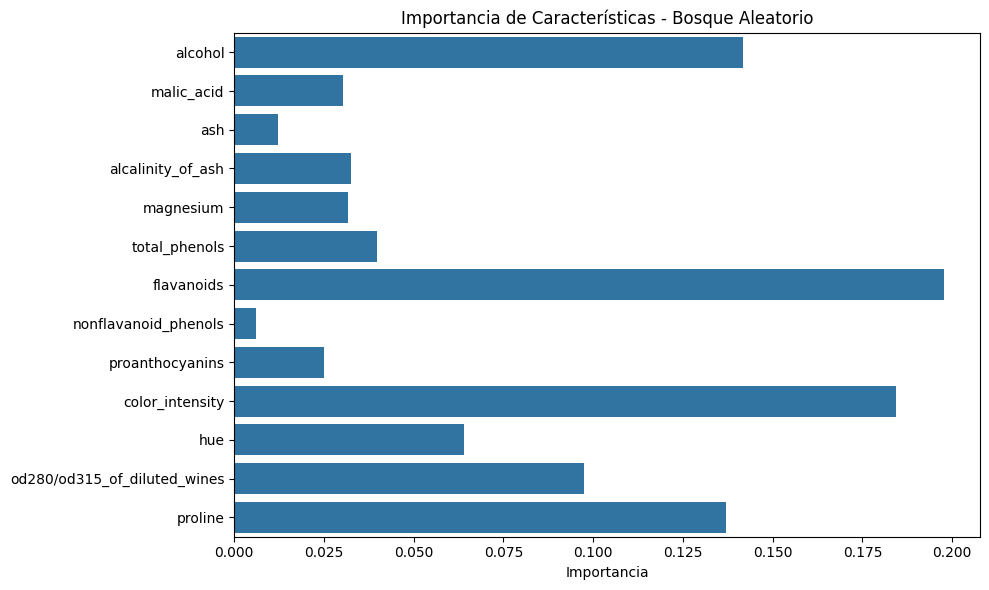

In [ ]:
# Visualizar importancia de características (Random Forest)
# Importancia de características
importancias = modelo_rf.feature_importances_
plt.figure(figsize=(10, 6))
sns.barplot(x=importancias, y=wine.feature_names)
plt.title("Importancia de Características - Bosque Aleatorio")
plt.xlabel("Importancia")
plt.tight_layout()
plt.show()

Gráfico de importancia de características generado por el modelo de Bosque Aleatorio (Random Forest) que entrenaste para clasificar tipos de vino en el dataset Wine.
Es un gráfico de barras horizontales que representa cuánto contribuye cada una de las 13 variables predictoras a las decisiones del modelo.

En el eje vertical (Y) tienes las variables (features) del vino.

En el eje horizontal (X) tienes un valor numérico de importancia relativa asignado por el modelo a cada variable.
La importancia de una característica en un modelo de Bosque Aleatorio indica cuánto mejora la pureza de los nodos (o reduce el error) al dividir los datos según esa característica.

A mayor importancia, más útil fue esa variable para predecir correctamente la clase del vino.

ariables más importantes en tu modelo:
Según tu gráfico, las características más influyentes fueron:

Variable	Interpretación
flavanoids	Compuestos fenólicos relacionados con el sabor y calidad
color_intensity	Intensidad del color del vino
alcohol	Porcentaje de alcohol
proline	Un aminoácido importante para el aroma y sabor
od280/od315_of_diluted_wines	Medida de polifenoles, que afectan el cuerpo y sabor.

Variables menos importantes:
nonflavanoid_phenols

ash

proanthocyanins

malic_acid

Estas no aportaron mucho a la capacidad del modelo para diferenciar entre clases. No quiere decir que sean inútiles en general, sino que en este modelo específico y con estos datos, no fueron decisivas.

¿Para qué sirve este análisis?
Para interpretar el modelo.

Para hacer selección de variables: podrías intentar reducir el número de variables y mantener buen rendimiento.

Para entender factores relevantes en la producción o clasificación del vino.



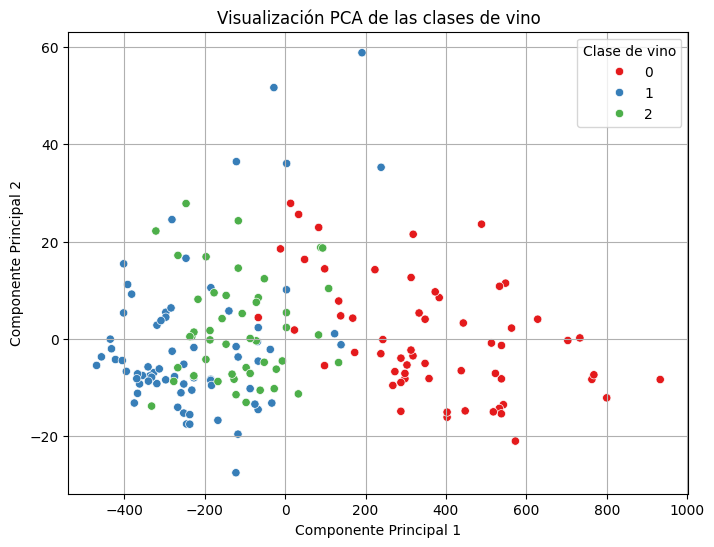

[0.99809123 0.00173592]
0.9998271461166032


In [ ]:
# Visualización PCA (reducción a 2D)
# PCA para reducir dimensiones
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Graficar los datos proyectados
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=wine.target, palette="Set1")
plt.title("Visualización PCA de las clases de vino")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.legend(title="Clase de vino")
plt.grid(True)
plt.show()

# cuánta varianza explican estos dos componentes
print(pca.explained_variance_ratio_)
print(pca.explained_variance_ratio_.sum())  # Total explicada por PC1 y PC2

El Análisis de Componentes Principales (PCA) es una técnica de reducción de dimensionalidad que transforma los datos originales (13 variables del vino) en nuevas variables no correlacionadas llamadas "componentes principales".

Estas nuevas variables están ordenadas por la cantidad de varianza (información) que explican.

En este gráfico se representan los dos primeros componentes principales (PC1 y PC2).

¿Qué muestra este gráfico?
Cada punto es un vino del dataset.

Los colores indican la clase real del vino:

🔴 Rojo: Clase 0

🔵 Azul: Clase 1

🟢 Verde: Clase 2

El eje X representa el Componente Principal 1.

El eje Y representa el Componente Principal 2.

Agrupamiento visual de clases
Se observa que:

🔴 La clase 0 (rojo) está bien separada del resto hacia la derecha.

🔵 La clase 1 (azul) está agrupada a la izquierda, con bastante cohesión.

🟢 La clase 2 (verde) está más dispersa y solapada entre clases 1 y 0.

Esto sugiere que:

El dataset es bastante separable, especialmente para las clases 0 y 1.

Puede haber algunos casos ambiguos entre clases 1 y 2.

2. Capacidad explicativa del PCA
Aunque solo se usan dos componentes principales, se puede observar una buena estructura de los datos, lo que significa que PC1 y PC2 contienen mucha de la varianza original.

¿Para qué sirve este gráfico?
Para visualizar relaciones y patrones entre las clases.

Para detectar clases bien separables y otras con solapamientos.

Para identificar casos difíciles de clasificar.

Como paso previo a aplicar algoritmos como SVM, K-NN, etc.

Primer componente principal (PC1) explica el 99.81% de la varianza del conjunto de datos.

Segundo componente principal (PC2) explica solo el 0.17% de la varianza.
La suma de los dos primeros componentes explica el 99.98% de toda la variabilidad de los datos originales (13 variables).

Esto significa que solamente con dos dimensiones (PC1 y PC2) estás capturando casi el 100% de la información original del dataset.

Por eso, el gráfico PCA que generaste refleja tan claramente la separación entre clases.



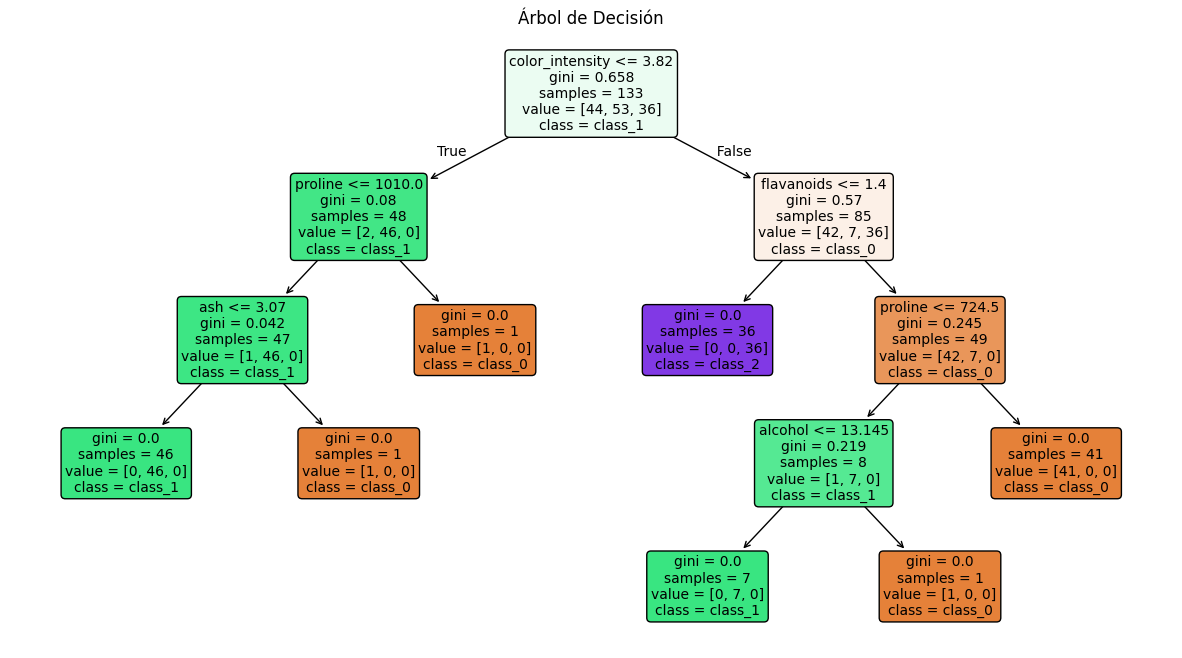

In [ ]:
# 7. Visualizar árbol de decisión
# Visualizar árbol (solo si se quiere entender las decisiones)
plt.figure(figsize=(15, 8))
plot_tree(modelo_dt, feature_names=wine.feature_names, class_names=wine.target_names,
          filled=True, rounded=True, fontsize=10)
plt.title("Árbol de Decisión")
plt.show()

¿Qué representa cada nodo del árbol?
Cada cuadro (nodo) representa una división (split) del conjunto de datos con base en una característica (por ejemplo, color_intensity, proline, etc.).

Elementos clave en cada nodo:
Condición de división (e.g., color_intensity <= 3.82)

gini: índice de impureza Gini (0 = puro, 0.5 = mezcla)

samples: número de muestras (filas) que llegan a ese nodo

value = [c0, c1, c2]: cantidad de muestras por clase

c0 = clase 0

c1 = clase 1

c2 = clase 2

class = class_X: clase predicha para ese nodo (mayoría)

Recorrido desde la raíz
Nodo raíz:
makefile
Copiar
Editar
color_intensity <= 3.82
gini = 0.658
samples = 133
value = [44, 53, 36]
class = class_1
Esto significa:

El árbol empieza evaluando si color_intensity ≤ 3.82.

Hay 133 muestras en total.

44 son clase 0, 53 clase 1, y 36 clase 2.

Como la clase mayoritaria es 1, se clasificarían como class_1 si no se dividiera más.

Rama izquierda (True): vinos con menor intensidad de color
División por proline <= 1010.0

Casi todos los vinos aquí resultan ser clase 1.

Más abajo se usa ash para terminar de separar completamente.

Resultado: casi todos los vinos con baja intensidad de color e intermedia proline son clase 1.

Rama derecha (False): vinos con color_intensity > 3.82
Primera división es flavanoids <= 1.4:

Si es falso (flavonoides > 1.4), entonces el vino es clase 2 (value = [0, 0, 36]).

Si es verdadero, se continúa dividiendo con proline y luego con alcohol.

Resultado: en esta rama se encuentran los vinos clase 0 y clase 2, separados principalmente por flavanoids, proline y alcohol.

Colores del árbol
Verde: nodos donde la clase predicha es class_1

Naranja: clase predicha es class_0

Púrpura: clase predicha es class_2

Los colores ayudan a ver la clase de salida más común en ese nodo.

¿Qué información útil extraemos?
Variables como color_intensity, flavanoids, proline, alcohol son muy importantes para la clasificación.

El árbol logra una segmentación bastante pura (gini ≈ 0 en muchos nodos hoja), lo que implica buena separación entre clases.

Es muy interpretativo: puedes saber cómo se toman las decisiones en el modelo paso a paso.